In [1]:
import torch
import numpy as np
import torchvision
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from torch.utils.data import random_split, TensorDataset, DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, RandomCrop, RandomHorizontalFlip

In [2]:
dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=ToTensor()
)

mean_r = (dataset.data[...,0].astype("float32") /255).mean()
mean_g = (dataset.data[...,1].astype("float32") /255).mean()
mean_b = (dataset.data[...,2].astype("float32") /255).mean()

std_r = (dataset.data[...,0].astype("float32") /255).std()
std_g = (dataset.data[...,1].astype("float32") /255).std()
std_b = (dataset.data[...,2].astype("float32") /255).std()

In [3]:
mean_r, mean_g, mean_b

(np.float32(0.49139968), np.float32(0.48215845), np.float32(0.4465309))

In [4]:
transform1 = torchvision.transforms.Compose([
    ToTensor(),
    Normalize((mean_r, mean_g, mean_b), (std_r, std_g, std_b))
])
transform2 = torchvision.transforms.Compose([
    RandomCrop(32, padding=4),
    RandomHorizontalFlip(),
    ToTensor(),
    Normalize((mean_r, mean_g, mean_b), (std_r, std_g, std_b)),

])

In [5]:
def data_load(transform, train: bool=True):
    dataset = datasets.CIFAR10(
        root=".data",
        train=train,
        download=True,
        transform=transform
    )

    return dataset

train_dataset = data_load(transform2, True)
t_v_dataset = data_load(transform1, False)

In [6]:
val_size = int(0.5 * len(t_v_dataset))
test_size = len(t_v_dataset) - val_size

val_dataset, test_dataset = random_split(t_v_dataset, lengths=(val_size, test_size))

In [7]:
class LeNet(torch.nn.Module):
    def __init__(self, in_channels: int=3, n_output: int=10):
        super().__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels, out_channels=24, kernel_size=5),
            torch.nn.BatchNorm2d(24),
            torch.nn.ReLU(),
            torch.nn.AvgPool2d(kernel_size=2),
            torch.nn.Conv2d(in_channels=24, out_channels=48, kernel_size=5),
            torch.nn.BatchNorm2d(48),
            torch.nn.ReLU(),
            torch.nn.AvgPool2d(2),
            torch.nn.Conv2d(in_channels=48, out_channels=256, kernel_size=5),
            torch.nn.BatchNorm2d(256),
            torch.nn.ReLU(),
            torch.nn.Flatten(), #чтобы убрало в конце ... 1,1
            torch.nn.Linear(in_features=256, out_features=128),
            torch.nn.BatchNorm1d(128),
            torch.nn.ReLU(),
            torch.nn.Dropout(),
            torch.nn.Linear(in_features=128, out_features=n_output)
        )

    def forward(self, x):
        return self.model(x)

In [8]:
model = LeNet(in_channels=3, n_output=10)
batch_size=128
EPOCHS = 200

In [9]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

criterion = torch.nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
sheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode="min", factor=0.5, patience=5)

Training LeNet:   0%|          | 0/200 [00:00<?, ?it/s]

LeNet on training [1/200]:   0%|          | 0/391 [00:00<?, ?it/s]

LeNet on validation [1/200]:   0%|          | 0/40 [00:00<?, ?it/s]

LeNet on training [2/200]:   0%|          | 0/391 [00:00<?, ?it/s]

LeNet on validation [2/200]:   0%|          | 0/40 [00:00<?, ?it/s]

...

LeNet on validation [198/200]:   0%|          | 0/40 [00:00<?, ?it/s]

LeNet on training [199/200]:   0%|          | 0/391 [00:00<?, ?it/s]

LeNet on validation [199/200]:   0%|          | 0/40 [00:00<?, ?it/s]

LeNet on training [200/200]:   0%|          | 0/391 [00:00<?, ?it/s]

LeNet on validation [200/200]:   0%|          | 0/40 [00:00<?, ?it/s]

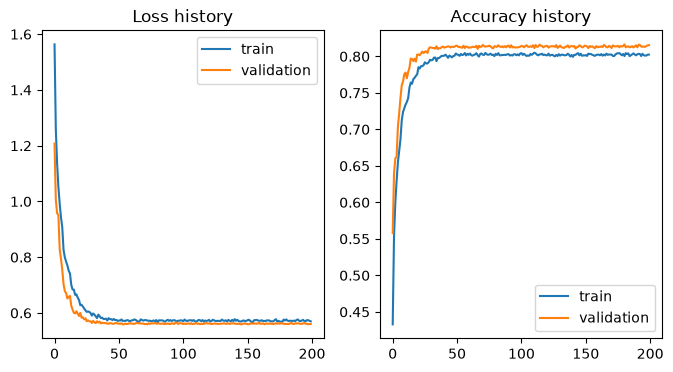

In [10]:
loop = tqdm(range(EPOCHS), desc="Training LeNet")
train_acc_history = []
train_loss_history = []
val_acc_history = []
val_loss_history = []
pred_loss_train = float("inf")
pred_loss_val = float("inf")

for epoch in loop:

    total = 0
    correct = 0
    losses = []

    model.train()
    loop_train = tqdm(enumerate(train_loader), desc=f"LeNet on training [{epoch+1}/{EPOCHS}]", total=len(train_loader), leave=False)
    for i, (images, targets) in loop_train:
        optim.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)

        losses.append(loss.item())

        temp_total = len(targets)
        total += temp_total
        temp_correct = torch.sum(torch.argmax(logits, axis=1) == targets).item()
        correct += temp_correct

        loss.backward()
        optim.step()

        if i % 10 == 0:
            loop_train.set_postfix(loss=loss.item(), accuracy=temp_correct/temp_total)

    train_acc_history.append(correct/total)
    train_loss_history.append(np.mean(losses))
    loop.set_postfix(mean_train_loss=train_loss_history[-1], mean_val_loss=pred_loss_val)
    pred_loss_train = train_loss_history[-1]

    total = 0
    correct = 0
    losses = []

    model.eval()
    loop_val = tqdm(enumerate(val_loader), desc=f"LeNet on validation [{epoch+1}/{EPOCHS}]", total=len(val_loader), leave=False)
    for i, (images, targets) in loop_val:
        with torch.no_grad():
            logits = model(images)
            loss = criterion(logits, targets)

            losses.append(loss.item())

            temp_total = len(targets)
            total += temp_total
            temp_correct = torch.sum(torch.argmax(logits, axis=1) == targets).item()
            correct += temp_correct

            if i % 10 == 0:
                loop_val.set_postfix(loss=loss.item(), accuracy=temp_correct/temp_total)

    val_acc_history.append(correct/total)
    val_loss_history.append(np.mean(losses))
    loop.set_postfix(mean_train_loss=pred_loss_train, mean_val_loss=val_loss_history[-1])
    pred_loss_val = val_loss_history[-1]

    sheduler.step(val_acc_history[-1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.plot(train_loss_history, label="train")
ax1.plot(val_loss_history, label="validation")
ax1.set_title("Loss history")
ax1.legend()

ax2.plot(train_acc_history, label="train")
ax2.plot(val_acc_history, label="validation")
ax2.set_title("Accuracy history")
ax2.legend()
